# The Last Mile Logistics Auditor
**Client:** Veridi Logistics | **Dataset:** Olist Brazilian E-Commerce

This notebook audits delivery performance by connecting logistics data (actual vs. estimated delivery dates) with customer sentiment (review scores) to identify where and why Veridi Logistics is failing its customers.

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Story 1 — The Schema Builder
1.Load the raw CSVs into the notebook

2.Join them into a single master dataset:

    -Join Reviews to Orders on order_id

    -Join Customers to Orders on customer_id

3.Check that you didn't accidentally duplicate rows

In [2]:
orders   = pd.read_csv('data/olist_orders_dataset.csv')
reviews  = pd.read_csv('data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
products  = pd.read_csv('data/olist_products_dataset.csv')
translation = pd.read_csv('data/product_category_name_translation.csv')

print('orders:   ', orders.shape)
print('reviews:  ', reviews.shape)
print('customers:', customers.shape)
print('products: ', products.shape)
print('translation: ', translation.shape)


orders:    (99441, 8)
reviews:   (99224, 7)
customers: (99441, 5)
products:  (32951, 9)
translation:  (71, 2)


In [3]:
# Deduplicate reviews — keep one review per order to avoid row duplication on join
reviews_deduped = reviews.drop_duplicates(subset='order_id', keep='last')

# Join: orders <- reviews <- customers
df = orders.merge(reviews_deduped[['order_id', 'review_score']], on='order_id', how='left')
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')

print('Master dataset shape:', df.shape)
print('Duplicate order_ids:', df['order_id'].duplicated().sum())
df.head()


Master dataset shape: (99441, 11)
Duplicate order_ids: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4.0,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4.0,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5.0,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,5.0,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,5.0,SP,santo andre


## 2. Story 2 — The "Real" Delay Calculator
Calculate delivery delay and classify orders.

In [4]:
# Parse dates
date_cols = ['order_purchase_timestamp', 'order_estimated_delivery_date', 'order_delivered_customer_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Exclude undelivered orders
df_delivered = df[df['order_status'] == 'delivered'].copy()
df_excluded  = df[df['order_status'].isin(['canceled', 'unavailable'])].copy()

print('Delivered orders:', len(df_delivered))
print('Excluded orders (canceled/unavailable):', len(df_excluded))

Delivered orders: 96478
Excluded orders (canceled/unavailable): 1234


In [5]:
# Drop rows missing either date before calculating
df_delivered = df_delivered.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])

# Days_Difference: positive = late, negative = early
df_delivered['days_difference'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_estimated_delivery_date']
).dt.days


def classify_delivery(days):
    if days > 5:
        return 'Super Late'
    elif days > 0:
        return 'Late'
    else:
        return 'On Time'

df_delivered['delivery_status'] = df_delivered['days_difference'].apply(classify_delivery)
df_delivered['delivery_status'].value_counts()

delivery_status
On Time       89936
Super Late     3764
Late           2770
Name: count, dtype: int64

## 3. Story 3 — The Geographic Heatmap
Which states have the highest % of late deliveries?

C:\Users\YSS\AppData\Local\Temp\ipykernel_10144\990890735.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_stats, x='customer_state', y='pct_late', palette='Reds_r')


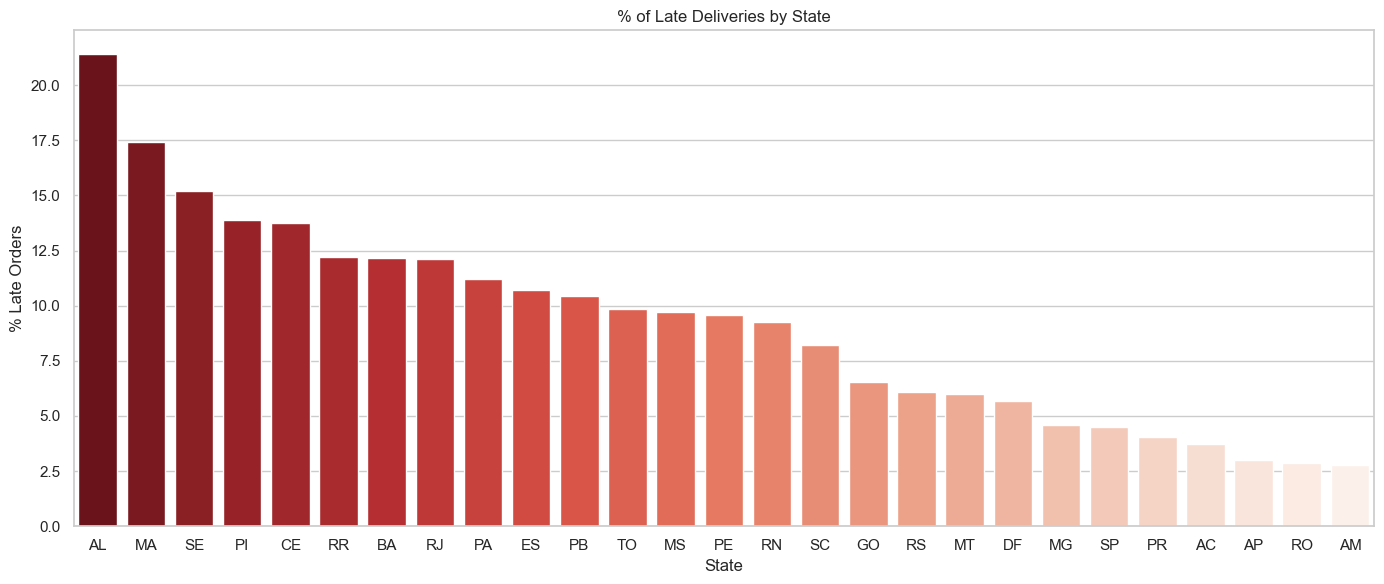

In [6]:
state_stats = df_delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x != 'On Time').sum())
).reset_index()

state_stats['pct_late'] = (state_stats['late_orders'] / state_stats['total_orders'] * 100).round(2)
state_stats = state_stats.sort_values('pct_late', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=state_stats, x='customer_state', y='pct_late', palette='Reds_r')
plt.title('% of Late Deliveries by State')
plt.xlabel('State')
plt.ylabel('% Late Orders')
plt.tight_layout()
plt.show()

## 4. Story 4 — The Sentiment Correlation
Do late deliveries cause bad reviews?

C:\Users\YSS\AppData\Local\Temp\ipykernel_10144\1006616104.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment, x='delivery_status', y='avg_review_score',


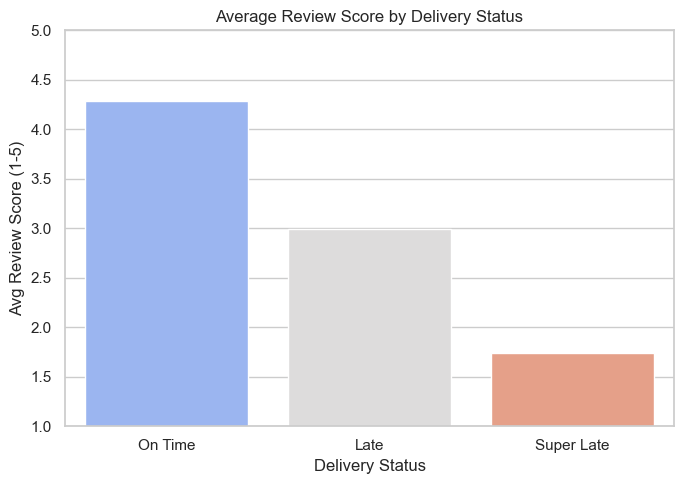

In [7]:
# Average review score by delivery status
sentiment = df_delivered.groupby('delivery_status')['review_score'].mean().reset_index()
sentiment.columns = ['delivery_status', 'avg_review_score']

plt.figure(figsize=(7, 5))
sns.barplot(data=sentiment, x='delivery_status', y='avg_review_score',
            order=['On Time', 'Late', 'Super Late'], palette='coolwarm')
plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Avg Review Score (1-5)')
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

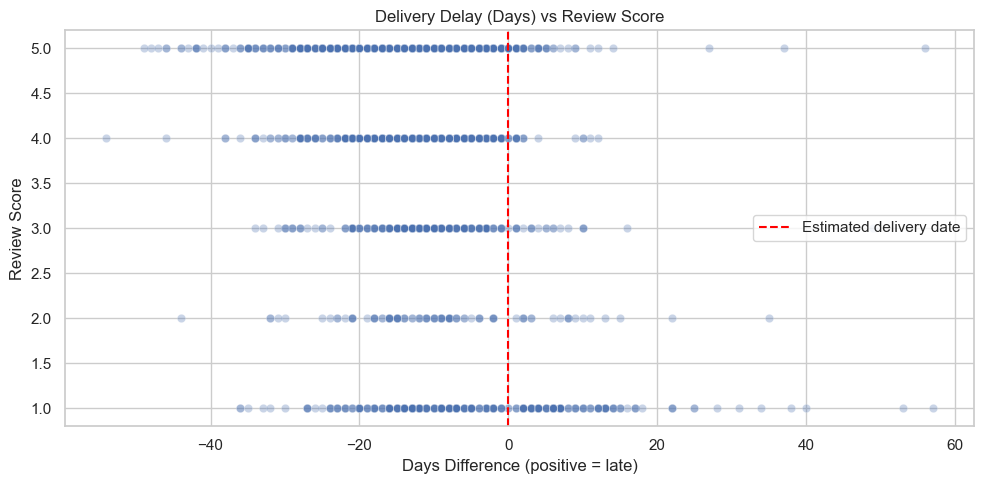

In [8]:
# Scatter: delay days vs review score
sample = df_delivered.dropna(subset=['days_difference', 'review_score']).sample(3000, random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample, x='days_difference', y='review_score', alpha=0.3)
plt.axvline(0, color='red', linestyle='--', label='Estimated delivery date')
plt.title('Delivery Delay (Days) vs Review Score')
plt.xlabel('Days Difference (positive = late)')
plt.ylabel('Review Score')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Bonus — The Translation Challenge
Translate product categories from Portuguese to English.

In [9]:
products_translated = products.merge(translation, on='product_category_name', how='left')
products_translated['category_en'] = products_translated['product_category_name_english'].fillna(
    products_translated['product_category_name']
)
products_translated[['product_id', 'product_category_name', 'category_en']].head()

,product_id,product_category_name,category_en
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## 6. Candidate's Choice

C:\Users\YSS\AppData\Local\Temp\ipykernel_10144\2787543693.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['delivery_status'] != 'On Time').sum() / len(x) * 100)


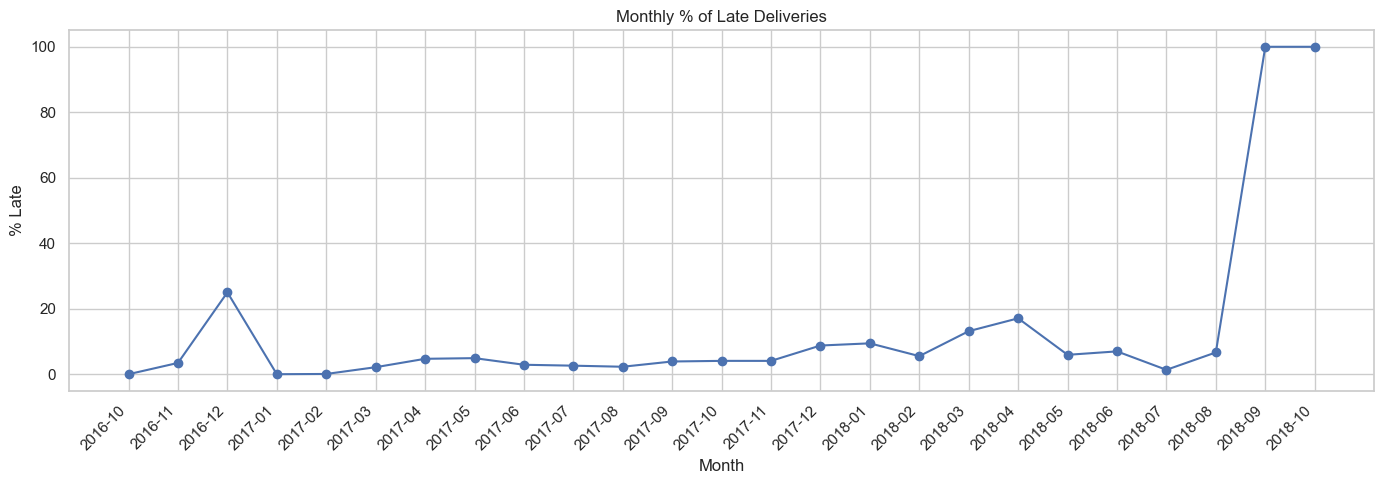

In [10]:
# Story 6 — Monthly Trend of Late Deliveries
monthly = df_delivered.copy()
monthly['month'] = monthly['order_delivered_customer_date'].dt.to_period('M')

monthly_trend = (
    monthly.groupby('month')
    .apply(lambda x: (x['delivery_status'] != 'On Time').sum() / len(x) * 100)
    .reset_index(name='pct_late')
)

monthly_trend['month'] = monthly_trend['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_trend['month'], monthly_trend['pct_late'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly % of Late Deliveries')
plt.ylabel('% Late')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


## 7. Export Master Dataset
Save the cleaned master dataset for use in the dashboard.

In [11]:
df_delivered.to_csv('data/master_dataset.csv', index=False)
print('Exported master_dataset.csv')

Exported master_dataset.csv
